In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from netmap.downstream.gene_clustering import *

In [3]:


def get_hierarchical_clustering_from_sim(sim_matrix, names, method='ward'):
    """
    Performs hierarchical clustering from a precomputed similarity matrix.

    Parameters
    ----------evaluation
    sim_matrix : np.ndarray
        A square similarity matrix (e.g., Jaccard Index).
    names : list
        List of labels (e.g., cell types) corresponding to matrix rows/cols.
    method : str
        Linkage method for scipy.cluster.hierarchy (e.g., 'ward', 'average').

    Returns
    -------
    df : pd.DataFrame
        Dataframe containing the flattened similarity and cophenetic distances.
    Z : np.ndarray
        The linkage matrix (Z) for plotting dendrograms.
    """
    # 1. Convert Similarity to Distance
    # Jaccard distance is defined as 1 - Jaccard similarity
    dist_matrix = 1 - sim_matrix
    
    # Ensure the diagonal is exactly 0 to avoid floating point issues
    np.fill_diagonal(dist_matrix, 0)

    # 2. Perform Hierarchical Clustering
    # squareform converts the square distance matrix into a condensed vector
    Z = hierarchy.linkage(squareform(dist_matrix), method=method)

    # 3. Calculate Cophenetic Correlation Metrics
    # Extracts the upper triangle indices (excluding diagonal) to flatten the matrix
    triu_idx = np.triu_indices(len(names), k=1)
    
    dist_linkage = hierarchy.average(sim_matrix)

    # Prepare data for quantile regression
    flatten_upper_triangular_excluding_diagonal = lambda m: m[np.triu_indices_from(m, k=1)]
    df = pd.DataFrame({
        'cophenet': hierarchy.cophenet(dist_linkage),
        'corr': flatten_upper_triangular_excluding_diagonal(sim_matrix)
    })
    
    return df, Z

def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

In [4]:
import numpy as np
np.random.seed(12)

In [5]:
cellmarker = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/Cell_marker_Seq.csv', sep='\t')

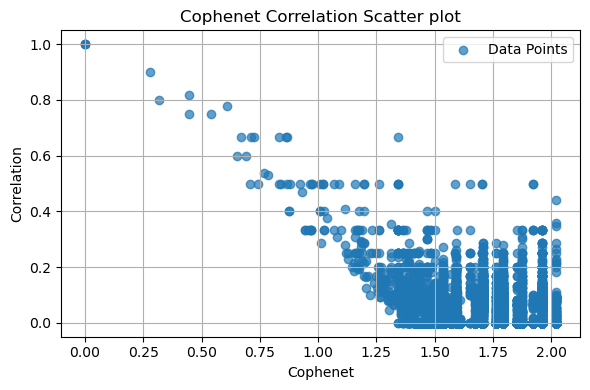

Automatically determined cluster cutoff distance: 1.1314


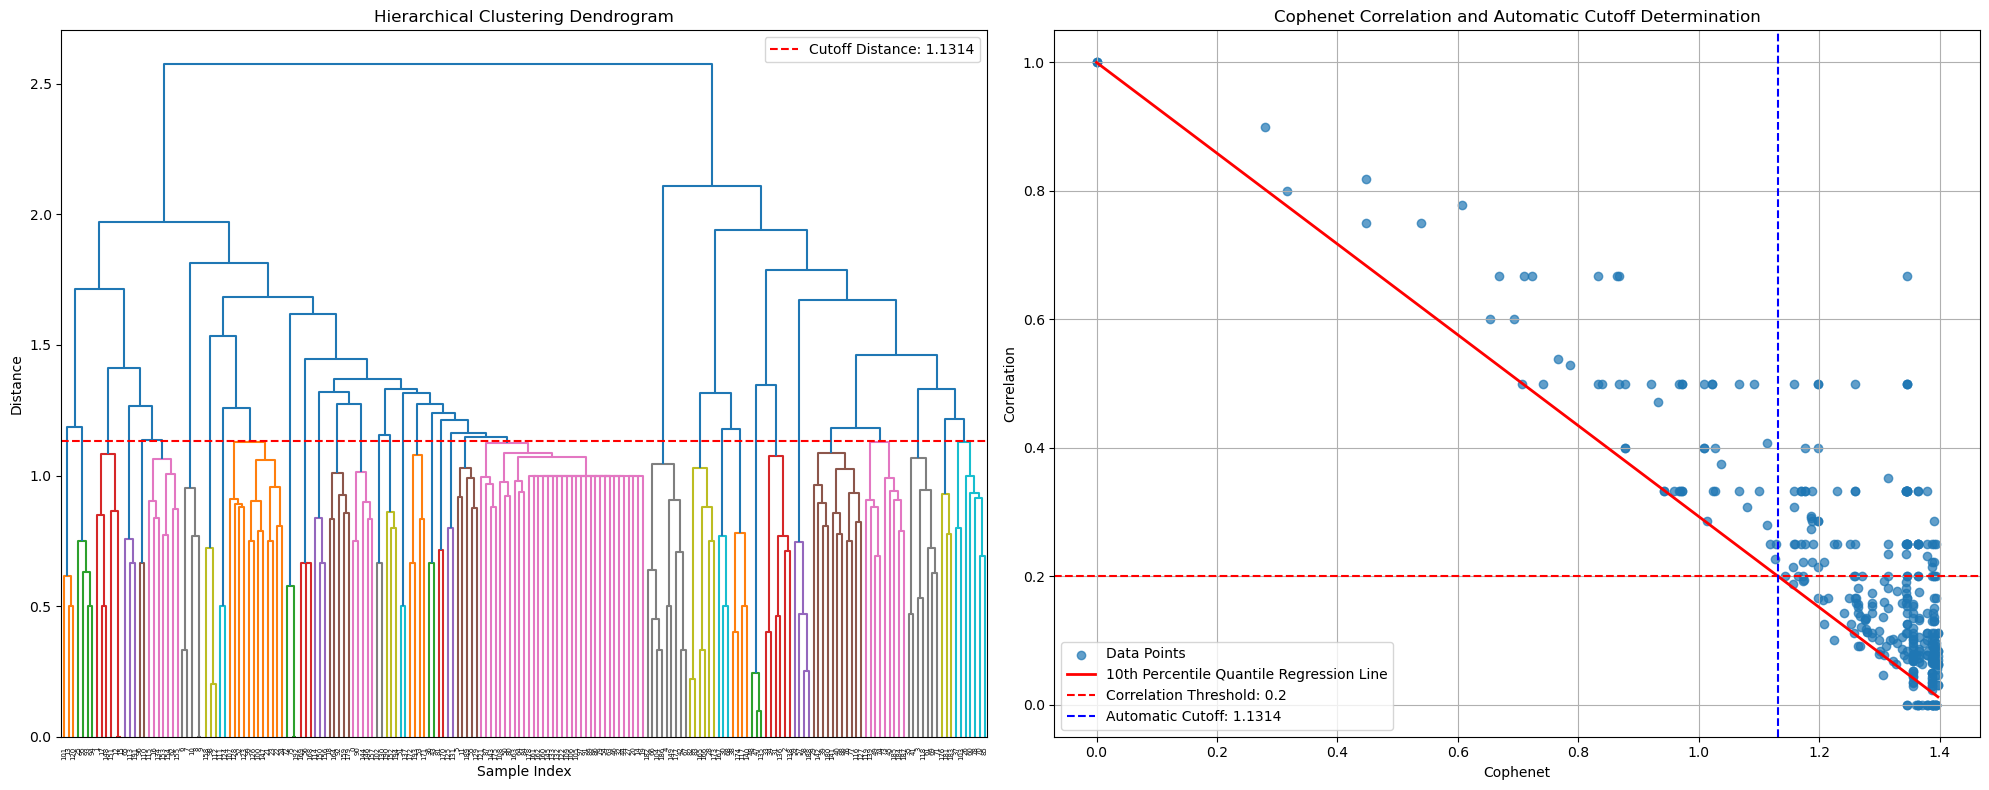

In [6]:

# 1. Prepare Data & Compute Jaccard Index
# Grouping markers into sets per cell type
cm = cellmarker[(cellmarker.tissue_type.isin(['Peripheral blood', 'Blood'])) & (cellmarker.species.isin(['Human']))]
marker_sets = cm.groupby('cell_name')['marker'].apply(set).to_dict()
names = list(marker_sets.keys())




# Create similarity matrix
n = len(names)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = jaccard_similarity(marker_sets[names[i]], marker_sets[names[j]])

df, Z = get_hierarchical_clustering_from_sim(sim_matrix, names)
plot_scatter_plot(df)
cutoff = compute_regression(df, 1.4, dist_linkage = Z, correlation_threshold=0.2)



In [7]:
from statsmodels.formula.api import quantreg
from scipy.cluster import hierarchy

clusters = hierarchy.fcluster(Z, t=1.27, criterion='distance')
dfclu = pd.DataFrame({'index':names, 'cluster' : clusters})
dfclu = dfclu.set_index('index')


In [8]:
cluster_map = {1: 'Memory B cells', 2: 'Activated B cells', 3: 'B cells/ Dendritic cells', 4: 'Activated T cell', 5: 'Neutrophils', 6 :'Monocytes', 7: 'Effector T cell', 8:'Cycling cells',
9: 'Megakaryocytes',  10: 'Stem cell', 11: 'Neutrophils', 12: 'Myeloid cells', 13: 'Naive circulating T cells', 14: 'T reg cells', 15: 'Not specific', 16: 'Activated/T helper cells', 17: 'Exhausted/proliferative T cells',
18: 'T cells (?)', 19: 'Central memory T cells', 20: 'Naive/Cytotoxic T cell', 21: 'Cytotoxic T cell', 22: 'Effector T cells/ NK cells', 23: 'Activated T cells/ Effector T cells', 24:'T cells/ NK cells'}

In [9]:
cluster_broad = {1: 'B cells', 2: 'B cells', 3: 'B cells/ Dendritic cells', 4: 'T cells', 5: 'Neutrophils', 6 :'Monocytes', 7: 'T cells', 8:'Cycling cells',
9: 'Megakaryocytes',  10: 'Stem cell', 11: 'Neutrophils', 12: 'Myeloid cells', 13: 'T cells', 14: 'T cells', 15: 'Not specific', 16: 'T cells', 17: 'T cells',
18: 'T cells', 19: 'T cells', 20: 'T cells', 21: 'T cells', 22: 'T cells/ NK cells', 23: 'T cells', 24:'T cells/ NK cells'}

In [10]:
dfclu['cluster_name'] = [cluster_map[c] for c in dfclu.cluster]
dfclu['cluster_high_level'] = [cluster_broad[c] for c in dfclu.cluster]


In [11]:
dfclu

,cluster,cluster_name,cluster_high_level
index,,,
Abnormal myeloid cell,11,Neutrophils,Neutrophils
Activated B cell,2,Activated B cells,B cells
Activated CD4+ T cell,20,Naive/Cytotoxic T cell,T cells
Activated CD8+ T cell,23,Activated T cells/ Effector T cells,T cells
Activated T cell,16,Activated/T helper cells,T cells
...,...,...,...
Tissue resident memory T(TRM) cell,12,Myeloid cells,Myeloid cells
Transitional B cell,3,B cells/ Dendritic cells,B cells/ Dendritic cells
Transitional CD8+ T cell,7,Effector T cell,T cells


In [12]:
dfclu.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/celltype_clustering.tsv', sep = '\t')

In [13]:
metamarker = {}
for clu in dfclu.cluster_name.unique():
    celltypes = dfclu[dfclu.cluster_name == clu]
    cluster_marker = cm[cm.cell_name.isin((celltypes.index))].marker.unique()
    print(cluster_marker)
    metamarker[clu] = cluster_marker

metamarker = pd.DataFrame([(k, v) for k, vals in metamarker.items() for v in vals], columns=['celltype', 'gene'])    

['Gfi3' 'Elane' 'Cepbe' 'PRTN3' 'ELANE' 'AZU1' 'CST7' 'CD43' 'CD10' 'CD16'
 'CD11b' 'CD15' 'CD66b' 'FCGR3B' 'MPO' 'CAMP' 'GATA2' 'LTF' 'CD101'
 'CD45d' 'CSF3R' 'CEACAM8' 'LCN2' 'DEFA4' 'CXCR2' 'ITGAM' 'S100A9'
 'S100A8' 'MMP8' 'LOX1' 'OLR1' 'CD11a' 'ITGAL' 'ARG1' 'CXCR1' 'MME' 'SELL'
 'CD55' 'LYZ' 'CTSG' 'CD64' 'CD49d']
['FCRL5' 'Tbet' 'CD19' 'CD11c' 'HLA-DR' 'CD33' 'CD11b' 'CD69' 'CD27' 'CD4'
 'HLADR' 'CD20']
['TCF7' 'LEF1' 'CCR7' 'RCAN3' 'MAL' 'NOSIP' 'SELL' 'SOCS3' 'TSHZ2' 'MYC'
 'CD28' 'CD3E' 'CD8A' 'CD4' 'CD8B' 'CD27' 'S1PR1' 'IL7Rhi' 'NELL2' 'FOXP1'
 'IL7R' 'S100A4' 'CD3D' 'CD62L' 'CD69' 'STAT3' 'ICOS' 'CCL5' 'NKG7' 'CCL4'
 'GZMB' 'PRF1' 'CCL3' 'CD154' 'CD3' 'CD8' 'CD197' 'HLADR' 'CD38']
['CD8A' 'FGFBP2' 'GZMH' 'GNLY' 'CD8' 'CD3' 'GZMA' 'PRF1' 'KLRG1' 'GZMB'
 'CX3CR1' 'NKG7' 'S1PR1' 'S1PR5' 'CD4' 'TBX21' 'CD3E' 'FCGR3A' 'CTSW'
 'CD8B' 'EOMES' 'CD3D' 'CD62L' 'CCL5' 'S100A4' 'GPR183' 'GZMK' 'KLRB1'
 'IFNG' 'AQP3' 'PRDM1' 'CD69' 'HLADR' 'CD38' 'CD127']
['CD4' 'CXCR5' 'CD3' 'CD8' 'CD

In [14]:
len(metamarker.celltype.unique())

23

In [15]:
metamarker.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/metamarkers.tsv')

In [16]:
from scipy.cluster.hierarchy import fcluster

# 1. Extract the 2 top-level clusters
# 't=2' specifies the number of clusters
# 'criterion='maxclust'' ensures we get exactly 2 groups
cluster_labels = fcluster(Z, t=2, criterion='maxclust')

# 2. Map labels back to cell names
cluster_mapping = pd.DataFrame({
    'cell_name': names,
    'cluster_id': cluster_labels
})

# 3. View the groups
group_1 = cluster_mapping[cluster_mapping['cluster_id'] == 1]['cell_name'].tolist()
group_2 = cluster_mapping[cluster_mapping['cluster_id'] == 2]['cell_name'].tolist()

print(f"Group 1: {group_1}")
print(f"Group 2: {group_2}")

Group 1: ['Abnormal myeloid cell', 'Activated B cell', 'Activated memory B cell', 'Activated memory CD8+ T cell', 'Activated memory T cell', 'Activated naive CD8+ T cell', 'Activated naive T cell', 'Activated natural killer cell', 'Age-associated B cell', 'Aged memory B cell', 'Antibody Secreting B cell', 'Astrocyte', 'Atypical memory B cell', 'B cell', 'B cell lineage', 'Basophil', 'Beta cell(β cell)', 'CAR-T cell', 'CD14 monocyte', 'CD14+ monocyte', 'CD16 monocyte', 'CD16+ monocyte', 'CD20+ B cell', 'CD3/CD28-stimulated T cell', 'CD4+ cytotoxic T lymphocyte', 'CD4+ tumor antigen-specific T (Tas) cell', 'CD8+ tumor antigen-specific T (Tas) cell', 'CD8+\xa0intraepithelial cell', 'Cancer stem cell', 'Cholangiocyte', 'Circulating memory T cell', 'Classical monocyte', 'Conventional T(Tconv) cell', 'Conventional dendritic cell 1(cDC1)', 'Conventional dendritic cell 2(cDC2)', 'Cycling cell', 'Dendritic cell', 'Dendritic cell lineage', 'Dermal cell', 'Dividing plasma B cell', 'Effector T(Tef

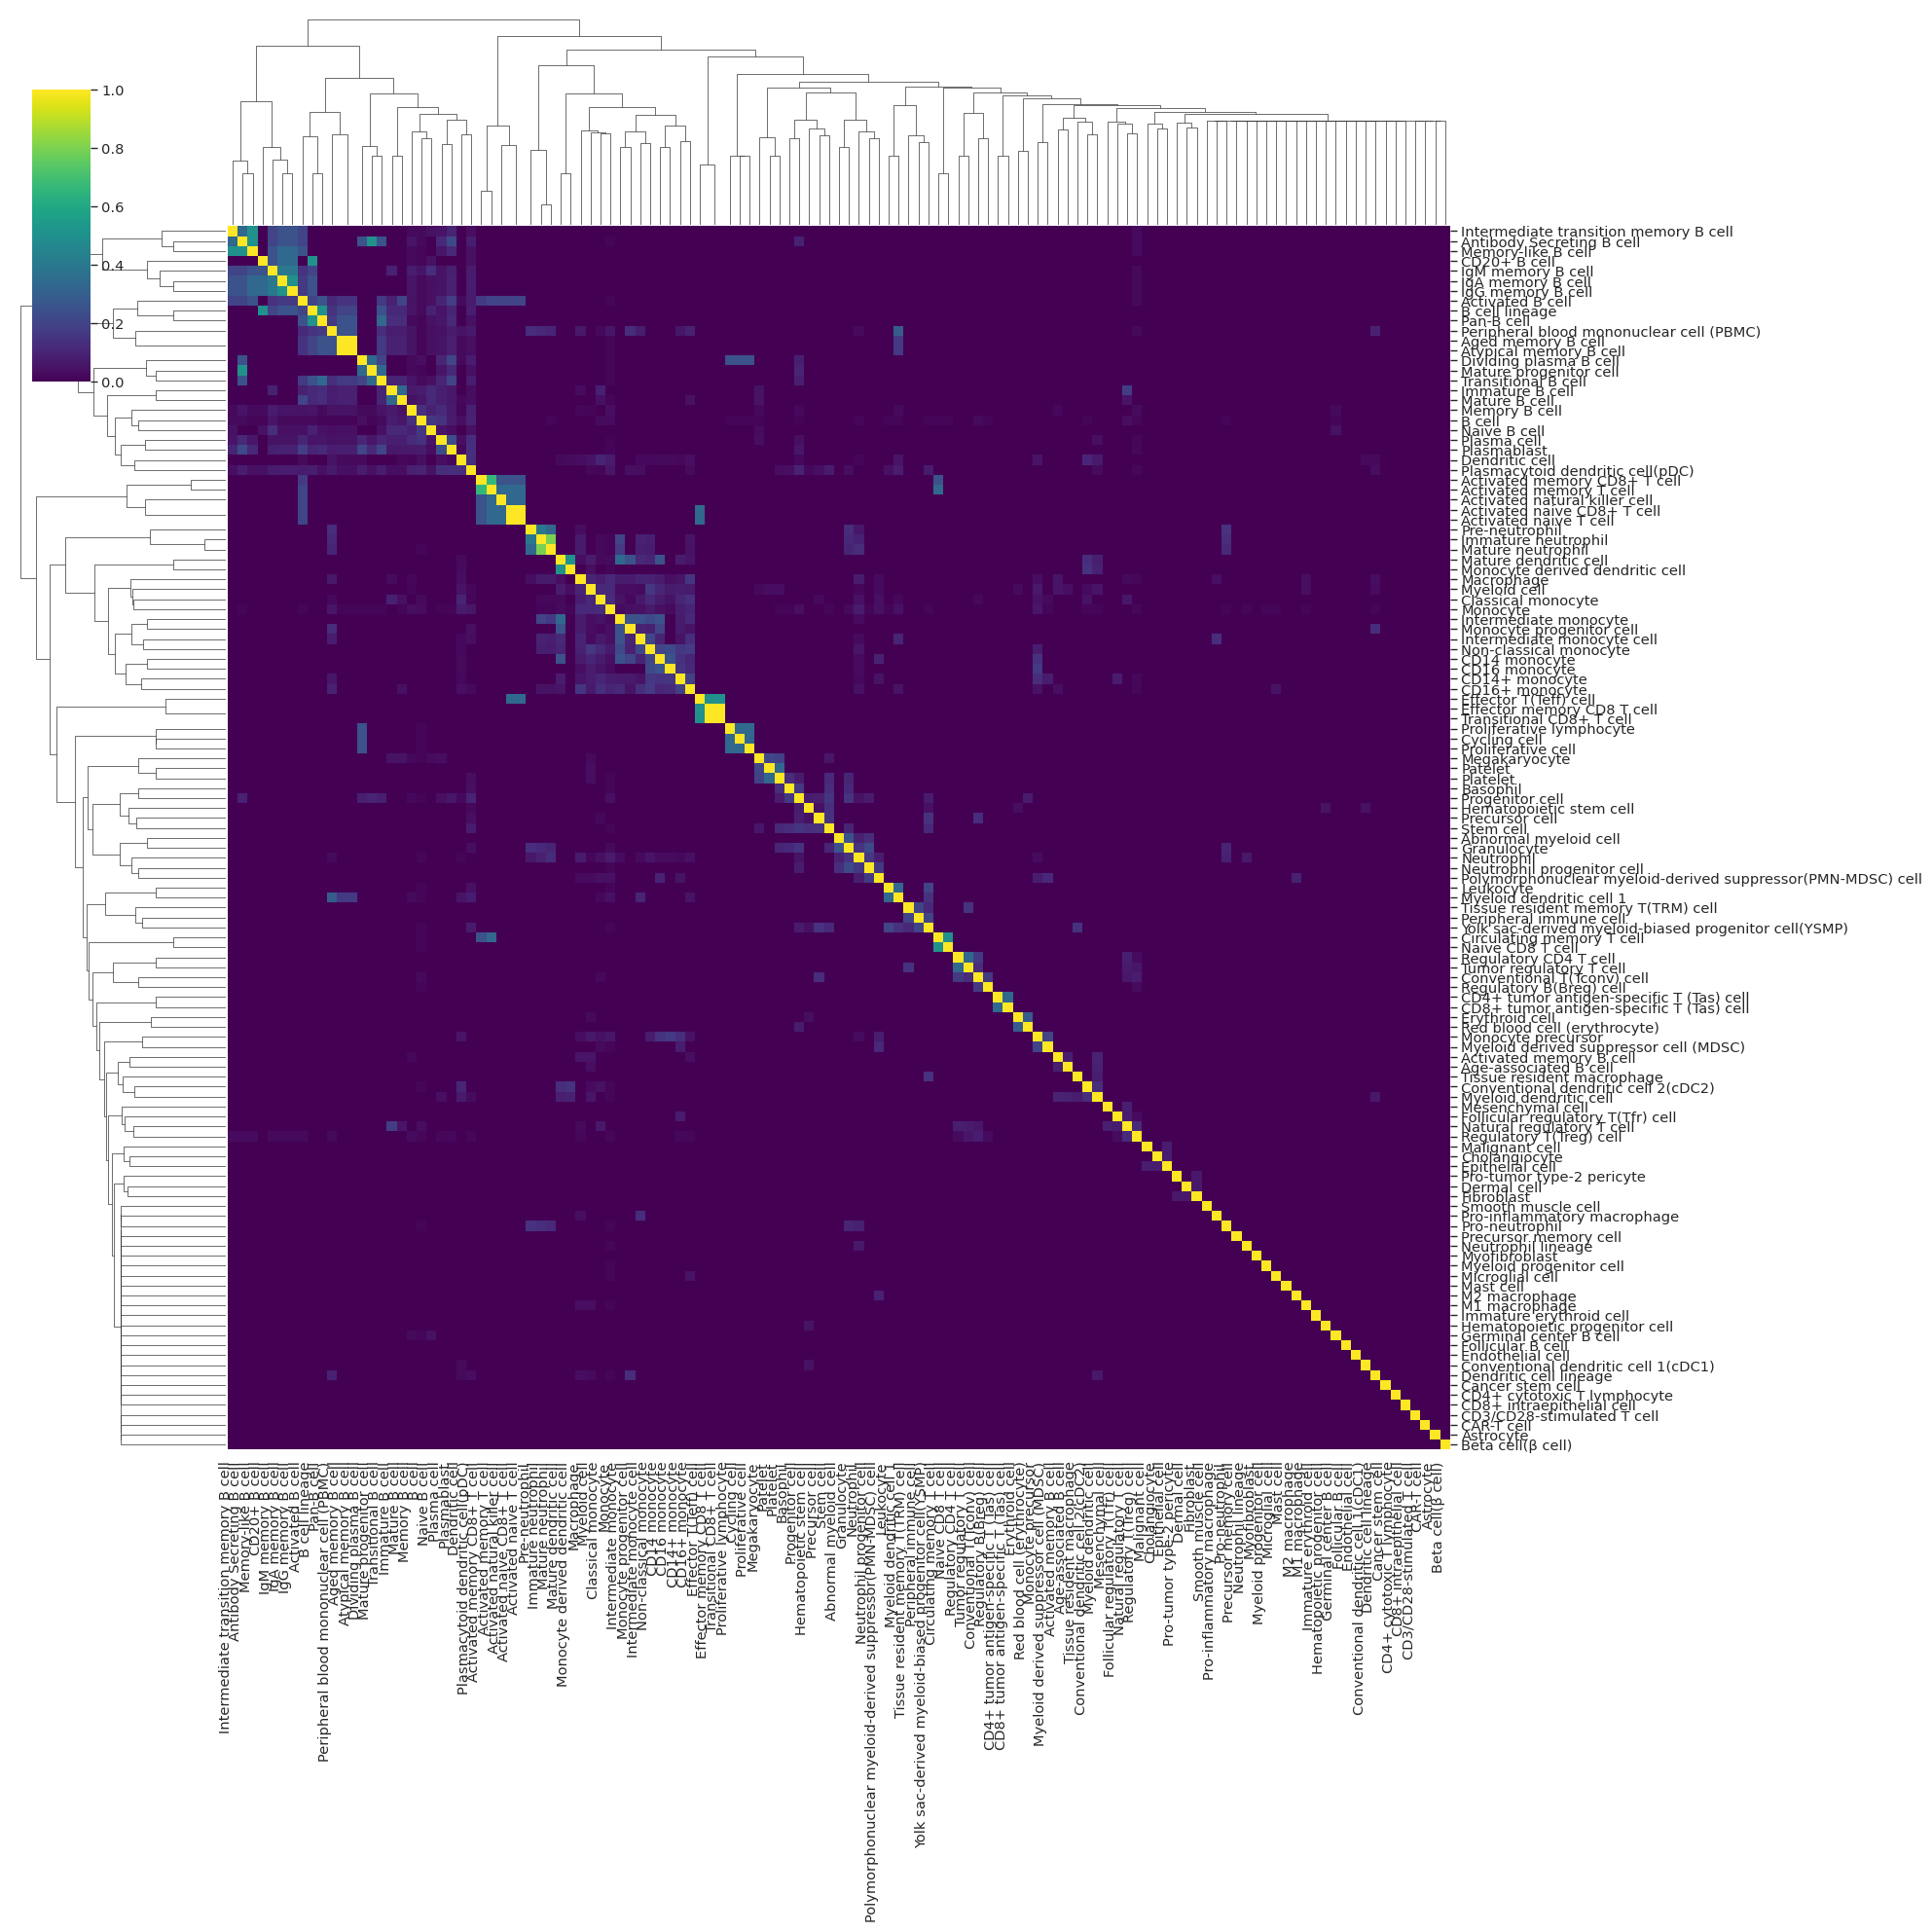

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# 1. Prepare Data & Compute Jaccard Index
# Grouping markers into sets per cell type
cm = cellmarker[(cellmarker.tissue_type.isin(['Peripheral blood', 'Blood'])) & (cellmarker.species.isin(['Human'])) & (cellmarker.cell_name.isin(group_1))]
marker_sets = cm.groupby('cell_name')['marker'].apply(set).to_dict()
names = list(marker_sets.keys())

def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

# Create similarity matrix
n = len(names)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = jaccard_similarity(marker_sets[names[i]], marker_sets[names[j]])

# 2. Compute Clustering
# Convert similarity to distance: Distance = 1 - Similarity
dist_matrix = 1 - sim_matrix
# Ensure it's a condensed distance matrix for scipy
condensed_dist = pdist(dist_matrix) # or use squareform if matrix is already distance-based
Z = linkage(squareform(dist_matrix), method='ward')

# 3. Show Heatmap with Dendrogram
df_sim = pd.DataFrame(sim_matrix, index=names, columns=names)
# Set aesthetic parameters for better readability
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.2)

# Create the clustermap
g = sns.clustermap(
    df_sim, 
    row_linkage=Z, 
    col_linkage=Z, 
    cmap='viridis',
    figsize=(20 ,20),      # Increased size for better spacing
    xticklabels=True,      # Ensure all labels are shown
    yticklabels=True,
    dendrogram_ratio=0.15, # Shrink dendrogram to give more room to the heatmap
    cbar_pos=(0.02, 0.8, 0.03, 0.15) # Move colorbar to avoid overlapping labels
)

# Rotate labels to prevent overlapping
plt.setp(g.ax_heatmap.get_xticklabels(), ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)


# Save the plot as a PDF  
plt.savefig("clustered_heatmap_others.pdf", format="pdf")

plt.show()